# TensorMesh GPU Demo — 3D Magnetostatics (Maxwell, curl–curl)

Solve $\nabla \times \nabla \times \mathbf{A} = \mathbf{J}$ in a cube containing a smooth z-directed current density (model of a thin wire) and recover the magnetic field $\mathbf{B} = \nabla \times \mathbf{A}$. Classic Maxwell-Ampère static problem.

What this demo shows:

1. **Multiple custom assemblers stacked into a saddle-point system** — `CurlCurl`, `DivStab`, `PressStab`, `PressCoupling` — six classes total, each a few lines of pure PyTorch.
2. **`SparseMatrix.combine([[A, B], [B.T, C]])`** — automatic block-COO combine of four separate sparse blocks into one global system.
3. **Nodal curl–curl with divergence-gauge stabilization** — fix the nullspace of `curl curl` (closed forms) by adding a pressure-like Lagrange multiplier with `∇p` coupling and a `(∇p, ∇q)` stabilization block.
4. **Mixed Dirichlet pattern** — tangential `A` is fixed component-by-component on different boundary faces; the Lagrange multiplier is pinned to zero on the full boundary.
5. **L2 projection of `curl A`** — a `MassElementAssembler.solve(...)` recovers a continuous nodal `B` from the discontinuous element-wise `curl A`.

**Problem**: unit cube, a Gaussian current concentrated along the z-axis through (0.5, 0.5). Tangential vector potential = 0 on the outer faces.

## 1. Setup

In [1]:
import time, warnings
warnings.filterwarnings('ignore')
import torch
import numpy as np
import matplotlib.pyplot as plt

from tensormesh import Condenser, ElementAssembler, MassElementAssembler, Mesh, NodeAssembler
from tensormesh.sparse import SparseMatrix

torch.set_default_dtype(torch.float64)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

device: cuda
GPU: NVIDIA A100 80GB PCIe


## 2. Assemblers — curl-curl + divergence gauge

The bare nodal $(\nabla \times u, \nabla \times v)$ form has a huge null space (closed forms). We restore well-posedness with a **mixed formulation** (vector potential `A` + scalar Lagrange multiplier `p`):

$$\begin{bmatrix} (\nabla\!\times u,\,\nabla\!\times v) + h^2 (\nabla\cdot u,\,\nabla\cdot v) & -(v,\,\nabla p) \\ -(\nabla q,\,u) & (\nabla q,\,\nabla p) \end{bmatrix}\begin{bmatrix} A \\ p \end{bmatrix} = \begin{bmatrix} (f, v) \\ 0 \end{bmatrix}.$$

In [2]:
class CurlCurl(ElementAssembler):
    def forward(self, gradu, gradv):
        z = torch.zeros_like(gradu[0])
        cu = torch.stack((torch.stack((z, -gradu[2], gradu[1])),
                          torch.stack((gradu[2], z, -gradu[0])),
                          torch.stack((-gradu[1], gradu[0], z))))
        cv = torch.stack((torch.stack((z, -gradv[2], gradv[1])),
                          torch.stack((gradv[2], z, -gradv[0])),
                          torch.stack((-gradv[1], gradv[0], z))))
        return cu.T @ cv


class DivStab(ElementAssembler):
    def __post_init__(self, h2=1.0):
        self.h2 = h2
    def forward(self, gradu, gradv):
        return self.h2 * torch.outer(gradu, gradv)


class PressStab(ElementAssembler):
    def forward(self, gradu, gradv):
        return gradu @ gradv


class PressCoupling(ElementAssembler):
    def __post_init__(self):
        self.component = 0
    def forward(self, u, gradv):
        return u * gradv[self.component]
    def __call__(self, *args, **kwargs):
        mats = []
        for c in range(self.dimension):
            self.component = c
            mats.append(super().__call__(*args, **kwargs))
        n_points = mats[0].shape[0]
        return SparseMatrix(
            -torch.cat([m.edata for m in mats]),
            torch.cat([self.dimension * m.row + c for c, m in enumerate(mats)]),
            torch.cat([m.col for m in mats]),
            shape=(self.dimension * n_points, n_points),
        )


class VectorLoad(NodeAssembler):
    def forward(self, v, f):
        return v * f


class CurlProjection(NodeAssembler):
    def forward(self, v, gradA):
        return v * torch.stack((gradA[2, 1] - gradA[1, 2],
                                gradA[0, 2] - gradA[2, 0],
                                gradA[1, 0] - gradA[0, 1]))

print('Assembler classes defined.')

Assembler classes defined.


## 3. Mesh, current source, BC masks"))

In [3]:
def current_source(points, cx, cy, radius, J0):
    dx = points[:, 0] - cx; dy = points[:, 1] - cy
    mag = J0 * torch.exp(-(dx ** 2 + dy ** 2) / (2 * radius ** 2))
    return torch.stack([torch.zeros_like(mag), torch.zeros_like(mag), mag], dim=1)


def tangential_mask(points, atol=1e-9):
    x, y, z = points[:, 0], points[:, 1], points[:, 2]
    on_x = (x.abs() < atol) | ((x - 1).abs() < atol)
    on_y = (y.abs() < atol) | ((y - 1).abs() < atol)
    on_z = (z.abs() < atol) | ((z - 1).abs() < atol)
    return torch.stack([on_y | on_z, on_x | on_z, on_x | on_y], dim=1).flatten().contiguous()


chara_length = 0.08
mesh = Mesh.gen_cube(chara_length=chara_length, order=1).double().to(device)
n_points = mesh.n_points
points = mesh.points
print(f'Mesh: {n_points} nodes, {mesh.n_elements} elements')

J0 = 100.0
current = current_source(points, 0.5, 0.5, radius=0.08, J0=J0)
print(f'Current peak: {current.norm(dim=1).max().item():.2f}')

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 30%] Meshing curve 4 (Line)
Info    : [ 40%] Meshing curve 5 (Line)
Info    : [ 50%] Meshing curve 6 (Line)
Info    : [ 60%] Meshing curve 7 (Line)
Info    : [ 60%] Meshing curve 8 (Line)
Info    : [ 70%] Meshing curve 9 (Line)
Info    : [ 80%] Meshing curve 10 (Line)
Info    : [ 90%] Meshing curve 11 (Line)
Info    : [100%] Meshing curve 12 (Line)
Info    : Done meshing 1D (Wall 0.000641676s, CPU 0s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Plane, Frontal-Delaunay)
Info    : [ 20%] Meshing surface 2 (Plane, Frontal-Delaunay)
Info    : [ 40%] Meshing surface 3 (Plane, Frontal-Delaunay)
Info    : [ 60%] Meshing surface 4 (Plane, Frontal-Delaunay)
Info    : [ 70%] Meshing surface 5 (Plane, Frontal-Delaunay)
Info    : [ 90%] Meshing surface 6 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.031117s, CPU 0.

Info    : 246 edge swaps, 3 node relocations (volume = 1): worst = 0.295717 / average = 0.784558 (Wall 0.00386709s, CPU 0.004336s)
Info    : 247 edge swaps, 3 node relocations (volume = 1): worst = 0.300491 / average = 0.78461 (Wall 0.00465207s, CPU 0.004749s)
Info    : No ill-shaped tets in the mesh :-)
Info    : 0.00 < quality < 0.10 :         0 elements
Info    : 0.10 < quality < 0.20 :         0 elements
Info    : 0.20 < quality < 0.30 :         0 elements
Info    : 0.30 < quality < 0.40 :       153 elements
Info    : 0.40 < quality < 0.50 :       290 elements
Info    : 0.50 < quality < 0.60 :       465 elements
Info    : 0.60 < quality < 0.70 :      1294 elements
Info    : 0.70 < quality < 0.80 :      2698 elements
Info    : 0.80 < quality < 0.90 :      3743 elements
Info    : 0.90 < quality < 1.00 :      1747 elements
Info    : Done optimizing mesh (Wall 0.0134789s, CPU 0.013635s)
Info    : 2315 nodes 12980 elements
Info    : Writing '.gmsh_cache/cube_0.0_1.0_0.0_1.0_0.0_1.0_0.08

Mesh: 2315 nodes, 10392 elements


Current peak: 100.00


## 4. Assemble the saddle-point block system

In [4]:
h2 = chara_length ** 2

t0 = time.time()
A_block = CurlCurl.from_mesh(mesh).to(device)()
Su      = DivStab.from_mesh(mesh, h2=h2).to(device)()
Sp      = PressStab.from_mesh(mesh).to(device)()
B_block = PressCoupling.from_mesh(mesh).to(device)()
if device.type == 'cuda':
    torch.cuda.synchronize()
print(f'Assembly time: {time.time()-t0:.2f} s')

K = SparseMatrix.combine([
    [A_block + Su,  B_block],
    [-1.0 * B_block.T, Sp],
])
print(f'K shape : {K.shape},  nnz = {K.values.numel()}')

rhs_u = VectorLoad.from_mesh(mesh).to(device)(point_data={'f': current}, batch_size=-1)
rhs_p = torch.zeros(n_points, dtype=points.dtype, device=device)
rhs = torch.cat([rhs_u, rhs_p])
print(f'RHS shape: {rhs.shape}')

Assembly time: 1.57 s
K shape : (9260, 9260),  nnz = 482416
RHS shape: torch.Size([9260])


## 5. Dirichlet BCs + cuDSS solve

In [5]:
dmask = torch.cat([tangential_mask(points), mesh.boundary_mask])
print(f'Dirichlet DOFs: {int(dmask.sum())} / {dmask.numel()}')

cond = Condenser(dmask, torch.zeros_like(rhs)).to(device)
K_red, rhs_red = cond(K, rhs)
print(f'K_red shape: {K_red.shape}')

t0 = time.time()
sol = cond.recover(K_red.solve(rhs_red, backend='cudss', method='lu', verbose=False))
if device.type == 'cuda':
    torch.cuda.synchronize()
print(f'Sparse solve: {time.time()-t0:.2f} s')

A = sol[:3 * n_points].reshape(n_points, 3)
print(f'||A||_inf = {A.abs().max().item():.4e}')

Dirichlet DOFs: 3794 / 9260
K_red shape: (5466, 5466)


Sparse solve: 0.37 s
||A||_inf = 1.1792e+00


## 6. Recover `B = curl A` by an L2 projection

`A` is in a $H^1$ nodal space, so `curl A` is element-wise discontinuous. We project it back to a continuous nodal field by solving `M B = ∫ v · curl A dV` componentwise, with the **mass matrix** $M$ assembled by the built-in `MassElementAssembler`.

In [6]:
M = MassElementAssembler.from_mesh(mesh).to(device)()
curl_rhs = CurlProjection.from_mesh(mesh).to(device)(point_data={'A': A}, batch_size=-1).reshape(n_points, 3)
t0 = time.time()
B = torch.stack([M.solve(curl_rhs[:, c], backend='cudss', method='lu', verbose=False) for c in range(3)], dim=1)
if device.type == 'cuda':
    torch.cuda.synchronize()
print(f'L2-projection (3 components): {time.time()-t0:.2f} s')
print(f'||B||_inf = {B.abs().max().item():.4e}')

L2-projection (3 components): 0.11 s
||B||_inf = 3.5102e+00


## 7. Visualize at the mid-z plane

Mid-z slab nodes: 204


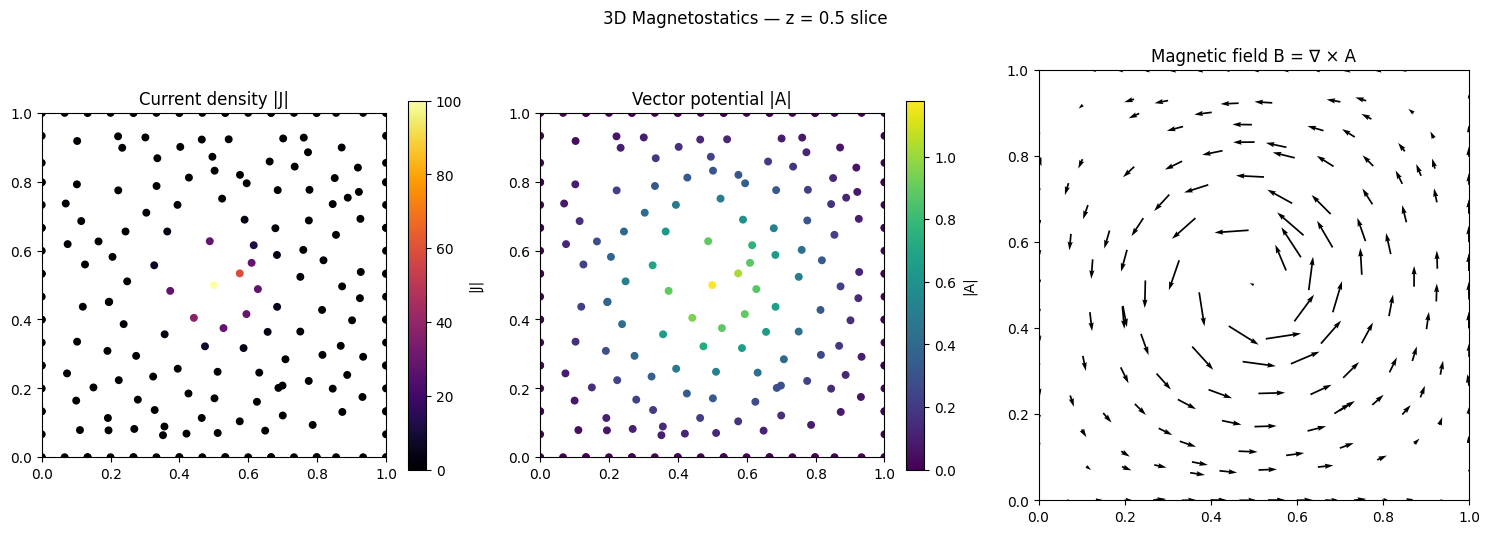

In [7]:
pts_np = points.cpu().numpy()
A_np = A.cpu().numpy()
B_np = B.cpu().numpy()
J_np = current.cpu().numpy()

slab = np.abs(pts_np[:, 2] - 0.5) < chara_length * 0.6
print(f'Mid-z slab nodes: {slab.sum()}')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax = axes[0]
sc = ax.scatter(pts_np[slab, 0], pts_np[slab, 1], c=np.linalg.norm(J_np[slab], axis=1), cmap='inferno', s=22)
plt.colorbar(sc, ax=ax, label='|J|', shrink=0.85)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
ax.set_title('Current density |J|')

ax = axes[1]
sc = ax.scatter(pts_np[slab, 0], pts_np[slab, 1], c=np.linalg.norm(A_np[slab], axis=1), cmap='viridis', s=22)
plt.colorbar(sc, ax=ax, label='|A|', shrink=0.85)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
ax.set_title('Vector potential |A|')

ax = axes[2]
B_xy = B_np[slab][:, :2]
scale = max(np.linalg.norm(B_xy, axis=1).max() * 12, 1e-6)
ax.quiver(pts_np[slab, 0], pts_np[slab, 1], B_xy[:, 0], B_xy[:, 1], scale=scale, width=0.004)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect('equal')
ax.set_title('Magnetic field B = ∇ × A')

plt.suptitle('3D Magnetostatics — z = 0.5 slice', y=1.02)
plt.tight_layout()
plt.savefig('maxwell_slice.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Radial dependence (Ampère's law check)

For a straight wire carrying current `I`, Ampère's law gives the azimuthal field at distance `r` as $B = \mu_0 I / (2\pi r)$. We bin the slice nodes by distance to the wire centerline and compare the magnitude of the azimuthal component.

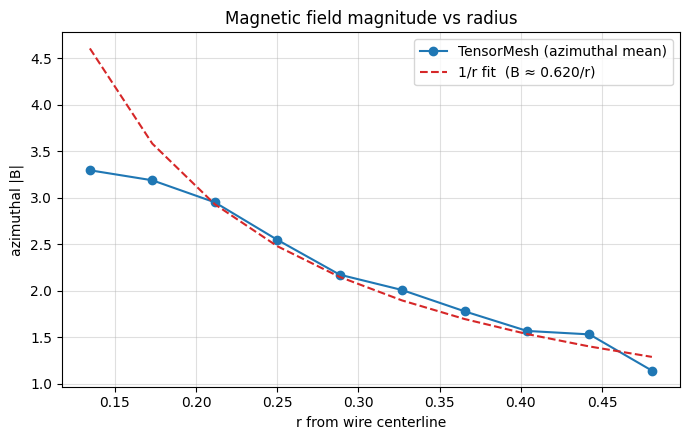

In [8]:
mid = slab
r = np.linalg.norm(pts_np[mid, :2] - np.array([0.5, 0.5]), axis=1)
B_az = np.abs(B_np[mid, 0] * (-(pts_np[mid, 1] - 0.5) / np.maximum(r, 1e-9)) +
              B_np[mid, 1] * ((pts_np[mid, 0] - 0.5) / np.maximum(r, 1e-9)))

# Bin
bins = np.linspace(0.0, 0.5, 14)
mids, vals = [], []
for i in range(len(bins) - 1):
    sel = (r >= bins[i]) & (r < bins[i + 1])
    if sel.sum() > 2:
        mids.append(0.5 * (bins[i] + bins[i + 1]))
        vals.append(B_az[sel].mean())

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(mids, vals, 'o-', label='TensorMesh (azimuthal mean)')
# Analytic 1/r scaled to fit far-field
r_fit = np.array(mids[-3:])
b_fit = np.array(vals[-3:])
C = (r_fit * b_fit).mean()
ax.plot(mids, C / np.array(mids), '--', color='C3', label=f'1/r fit  (B ≈ {C:.3f}/r)')
ax.set_xlabel('r from wire centerline'); ax.set_ylabel('azimuthal |B|')
ax.set_title('Magnetic field magnitude vs radius'); ax.grid(True, alpha=0.4); ax.legend()
plt.tight_layout()
plt.savefig('maxwell_ampere.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Summary

* Built a **stabilized nodal curl–curl** formulation from 5 lightweight `ElementAssembler` / `NodeAssembler` subclasses.
* Combined them into a single saddle-point sparse matrix with `SparseMatrix.combine([[A, B], [B.T, C]])`.
* Solved on the GPU with cuDSS direct LU.
* Recovered `B = curl A` via L2 projection (mass matrix solve).
* The mid-plane slice shows the expected azimuthal `B` field around the wire, with a 1/r decay in the far field.

For full-vector 3D problems where edge elements are physically required (e.g. Eddy-current with material jumps), Nédélec elements are on the [TensorMesh roadmap](https://github.com/camlab-ethz/TensorMesh/blob/main/ROADMAP.md). For the smooth current densities used here, the stabilized nodal formulation is already accurate.